# Dataset Distribution Analysis

This notebook analyzes the distribution of states, actions, and other data in the robot learning dataset.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Error.  nthreads must be a positive integer

## Load All Episodes

In [2]:
# Configuration
base_dir = Path("/root/autodl-tmp/data_lerobot")

# Find all episode folders
episode_folders = sorted(list(base_dir.rglob("episode_*")))
episode_folders = [f for f in episode_folders if f.is_dir() and (f / "episode_data.pkl").exists()]

print(f"Found {len(episode_folders)} episodes")
print(f"\nDataset structure:")

# Count by category
categories = {}
for ep in episode_folders:
    parent = ep.parent.name
    categories[parent] = categories.get(parent, 0) + 1

for cat, count in sorted(categories.items()):
    print(f"  {cat}: {count} episodes")

Found 100 episodes

Dataset structure:
  20260102_success: 40 episodes
  20260107_failure: 30 episodes
  20260107_success: 30 episodes


In [3]:
# Load all episode data
print("Loading all episodes...")

all_states = []
all_actions = []
all_qvels = []
all_eef_pos = []
episode_lengths = []
episode_durations = []
episode_categories = []

for ep_folder in tqdm(episode_folders):
    pkl_file = ep_folder / "episode_data.pkl"
    
    try:
        with open(pkl_file, 'rb') as f:
            data = pickle.load(f)
        
        frames = data['frames']
        
        # Extract data from all frames
        for frame in frames:
            all_states.append(frame['observation']['state'])
            all_actions.append(frame['action'])
            all_qvels.append(frame['observation']['qvel'])
            all_eef_pos.append(frame['observation']['eef_pos'])
        
        # Episode metadata
        episode_lengths.append(len(frames))
        episode_durations.append(data['duration'])
        
        # Category (success/failure)
        parent_name = ep_folder.parent.name
        if 'success' in parent_name.lower():
            episode_categories.append('success')
        elif 'failure' in parent_name.lower():
            episode_categories.append('failure')
        else:
            episode_categories.append('unknown')
            
    except Exception as e:
        print(f"Error loading {ep_folder.name}: {e}")

# Convert to numpy arrays
all_states = np.array(all_states)
all_actions = np.array(all_actions)
all_qvels = np.array(all_qvels)
all_eef_pos = np.array(all_eef_pos)
episode_lengths = np.array(episode_lengths)
episode_durations = np.array(episode_durations)

print(f"\nData loaded:")
print(f"  Total frames: {len(all_states):,}")
print(f"  States shape: {all_states.shape}")
print(f"  Actions shape: {all_actions.shape}")
print(f"  Qvel shape: {all_qvels.shape}")
print(f"  EEF pos shape: {all_eef_pos.shape}")
print(f"  Episodes: {len(episode_lengths)}")

Loading all episodes...


100%|██████████| 100/100 [00:00<00:00, 424.58it/s]


Data loaded:
  Total frames: 33,865
  States shape: (33865, 16)
  Actions shape: (33865, 16)
  Qvel shape: (33865, 14)
  EEF pos shape: (33865, 12)
  Episodes: 100


## Episode Length Distribution

Episode Length Statistics:
Mean: 338.6 frames (15.93 seconds)
Std: 70.8 frames (3.29 seconds)
Min: 211 frames (10.76 seconds)
Max: 541 frames (26.81 seconds)
Median: 326.5 frames (15.19 seconds)


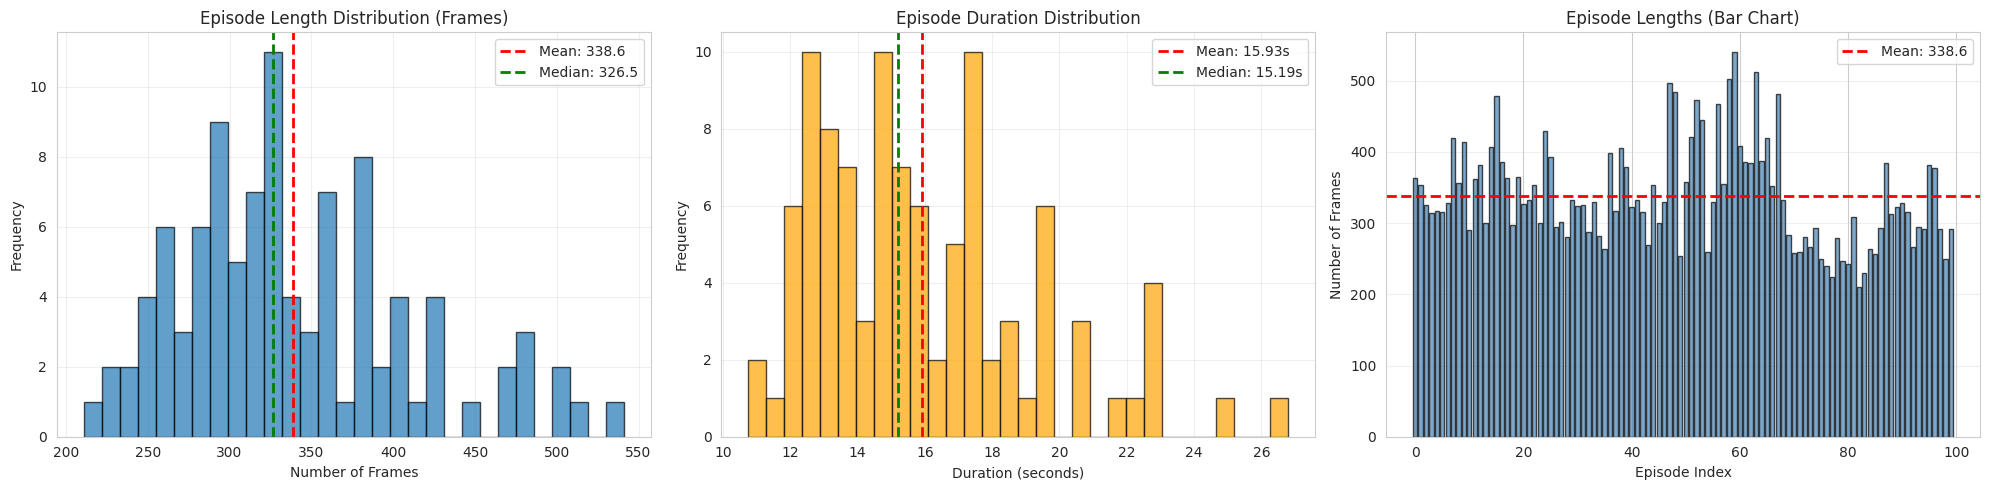

In [4]:
# Episode length statistics
print("Episode Length Statistics:")
print("=" * 60)
print(f"Mean: {episode_lengths.mean():.1f} frames ({episode_durations.mean():.2f} seconds)")
print(f"Std: {episode_lengths.std():.1f} frames ({episode_durations.std():.2f} seconds)")
print(f"Min: {episode_lengths.min()} frames ({episode_durations.min():.2f} seconds)")
print(f"Max: {episode_lengths.max()} frames ({episode_durations.max():.2f} seconds)")
print(f"Median: {np.median(episode_lengths):.1f} frames ({np.median(episode_durations):.2f} seconds)")

# Plot episode length distribution
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Histogram of frame counts
axes[0].hist(episode_lengths, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(episode_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {episode_lengths.mean():.1f}')
axes[0].axvline(np.median(episode_lengths), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(episode_lengths):.1f}')
axes[0].set_xlabel('Number of Frames')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Episode Length Distribution (Frames)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of durations
axes[1].hist(episode_durations, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(episode_durations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {episode_durations.mean():.2f}s')
axes[1].axvline(np.median(episode_durations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(episode_durations):.2f}s')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Episode Duration Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Bar chart of episode lengths
episode_indices = np.arange(len(episode_lengths))
axes[2].bar(episode_indices, episode_lengths, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axhline(episode_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {episode_lengths.mean():.1f}')
axes[2].set_xlabel('Episode Index')
axes[2].set_ylabel('Number of Frames')
axes[2].set_title('Episode Lengths (Bar Chart)')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Compare Success vs Failure Episodes

Success episodes: 70
  Mean length: 318.6 frames
  Std: 55.1 frames

Failure episodes: 30
  Mean length: 385.3 frames
  Std: 80.5 frames


/tmp/ipykernel_3012/2453203376.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=['Success', 'Failure'], patch_artist=True)


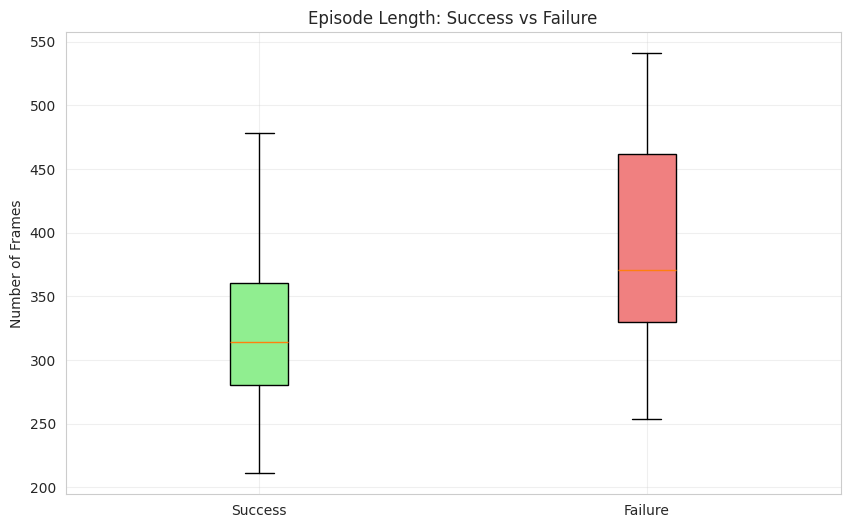

In [5]:
# Separate by category
success_lengths = [episode_lengths[i] for i in range(len(episode_lengths)) if episode_categories[i] == 'success']
failure_lengths = [episode_lengths[i] for i in range(len(episode_lengths)) if episode_categories[i] == 'failure']

print(f"Success episodes: {len(success_lengths)}")
print(f"  Mean length: {np.mean(success_lengths):.1f} frames")
print(f"  Std: {np.std(success_lengths):.1f} frames")
print(f"\nFailure episodes: {len(failure_lengths)}")
print(f"  Mean length: {np.mean(failure_lengths):.1f} frames")
print(f"  Std: {np.std(failure_lengths):.1f} frames")

# Box plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
box_data = [success_lengths, failure_lengths]
bp = ax.boxplot(box_data, labels=['Success', 'Failure'], patch_artist=True)

# Color the boxes
colors = ['lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Number of Frames')
ax.set_title('Episode Length: Success vs Failure')
ax.grid(True, alpha=0.3)
plt.show()

## Joint State Distribution

In [6]:
# State statistics
print("Joint State Statistics (16 dimensions):")
print("=" * 60)
print(f"Shape: {all_states.shape}")
print(f"\nPer-dimension statistics:")
print(f"{'Dim':<5} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for i in range(all_states.shape[1]):
    print(f"{i:<5} {all_states[:, i].mean():<12.6f} {all_states[:, i].std():<12.6f} {all_states[:, i].min():<12.6f} {all_states[:, i].max():<12.6f}")

Joint State Statistics (16 dimensions):
Shape: (33865, 16)

Per-dimension statistics:
Dim   Mean         Std          Min          Max         
------------------------------------------------------------
0     0.161467     0.327726     -2.245268    0.721834    
1     0.171593     0.141826     -0.387211    0.629795    
2     0.480849     0.408039     -0.404084    2.438131    
3     1.963113     0.180865     1.245868     2.495427    
4     -0.233394    0.326070     -1.717819    0.748822    
5     -0.644873    0.222214     -1.397576    0.359886    
6     -0.065641    0.793446     -1.972652    1.901561    
7     0.372810     0.399130     0.011765     0.913725    
8     -0.001750    0.000006     -0.001774    -0.001726   
9     0.000000     0.000009     -0.000024    0.000060    
10    0.698129     0.000010     0.698093     0.698201    
11    1.919860     0.000010     1.919777     1.919885    
12    -0.349074    0.000028     -0.349352    -0.349041   
13    -0.698137    0.000017     -0.698297

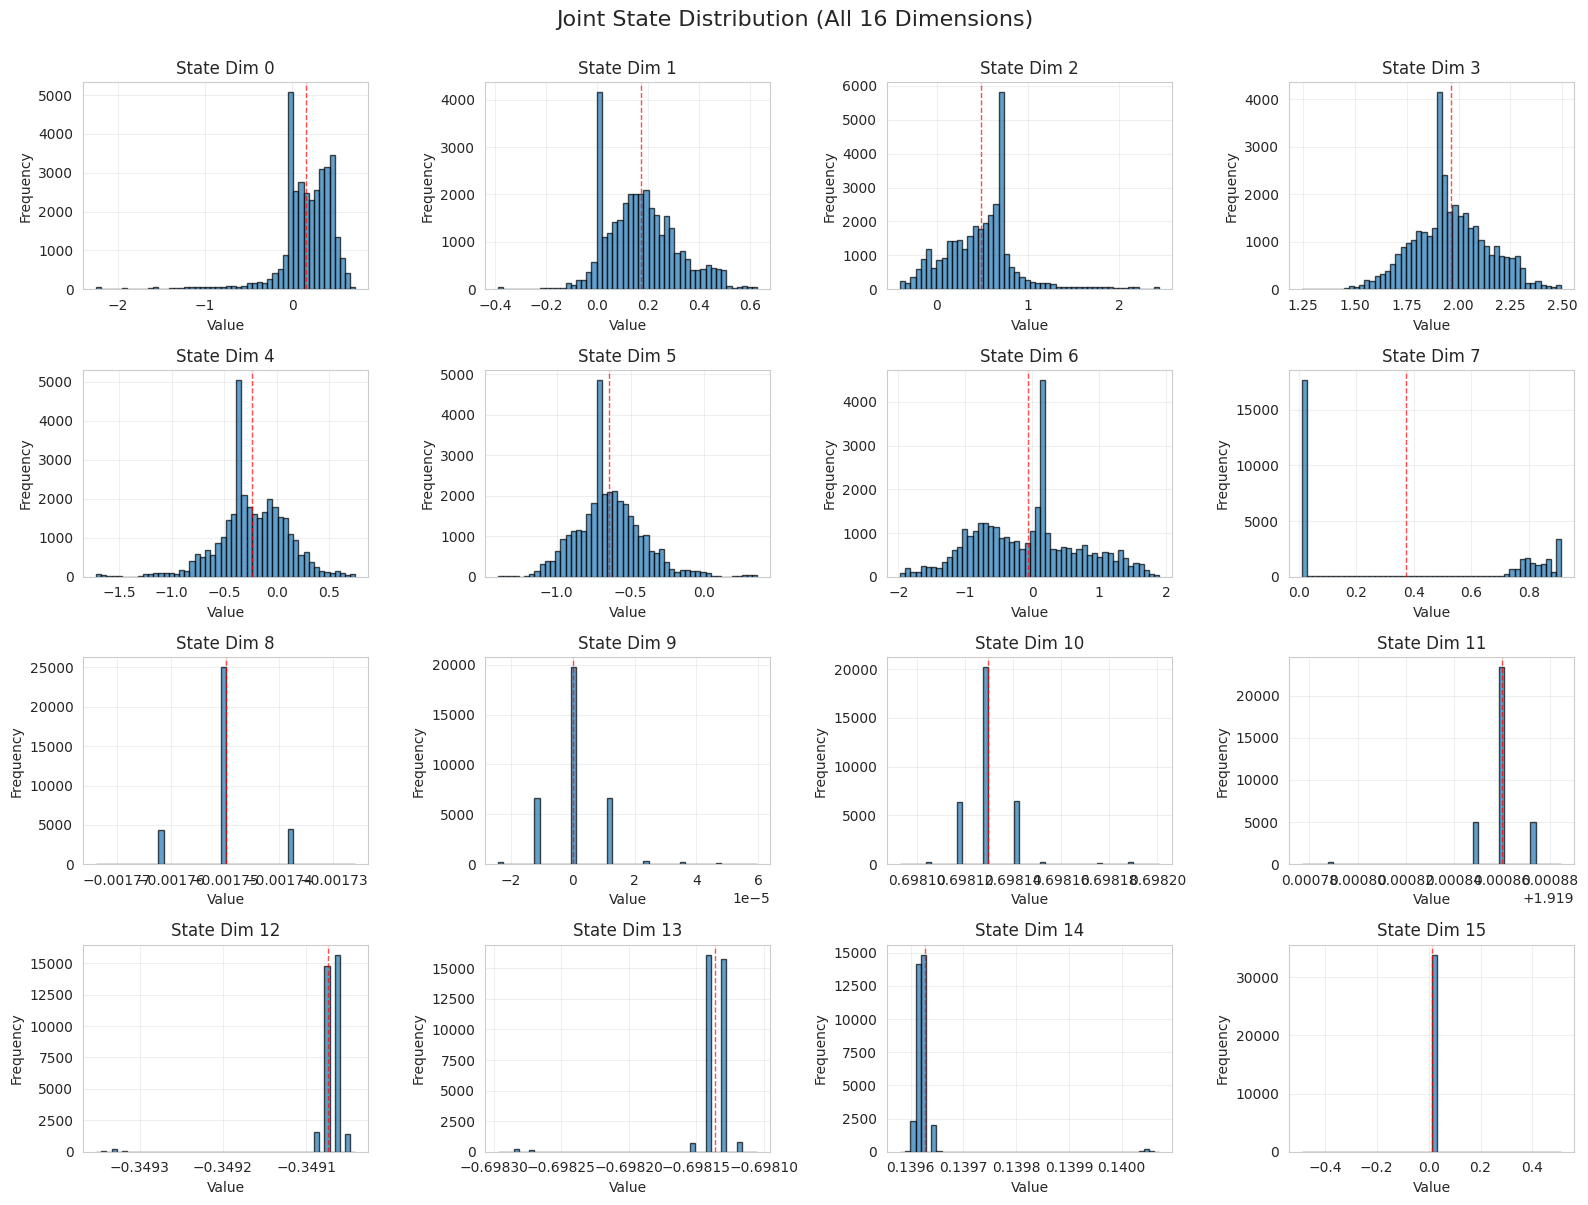

In [7]:
# Plot state distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(16):
    axes[i].hist(all_states[:, i], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'State Dim {i}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # Add mean line
    mean_val = all_states[:, i].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Joint State Distribution (All 16 Dimensions)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3012/423874425.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([all_states[:, i] for i in range(16)],


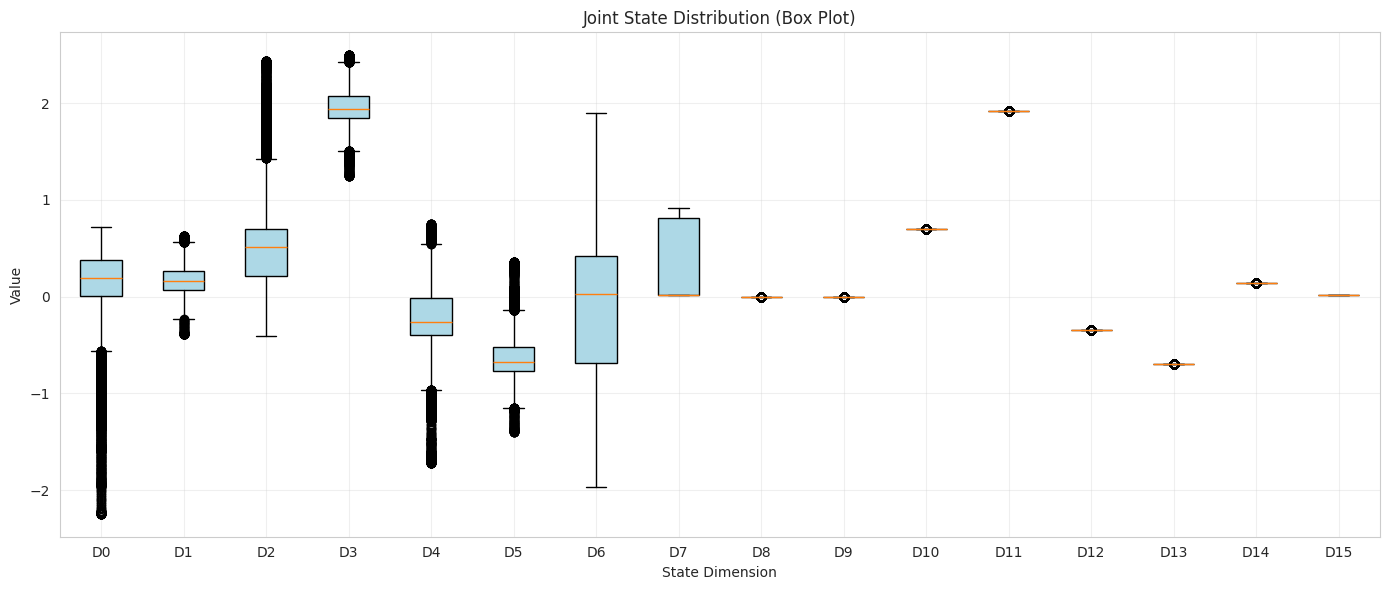

In [8]:
# Box plot for all state dimensions
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot([all_states[:, i] for i in range(16)], 
                 labels=[f'D{i}' for i in range(16)],
                 patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax.set_xlabel('State Dimension')
ax.set_ylabel('Value')
ax.set_title('Joint State Distribution (Box Plot)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Robot Action Distribution

In [9]:
# Action statistics
print("Robot Action Statistics (16 dimensions):")
print("=" * 60)
print(f"Shape: {all_actions.shape}")
print(f"\nPer-dimension statistics:")
print(f"{'Dim':<5} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for i in range(all_actions.shape[1]):
    print(f"{i:<5} {all_actions[:, i].mean():<12.6f} {all_actions[:, i].std():<12.6f} {all_actions[:, i].min():<12.6f} {all_actions[:, i].max():<12.6f}")

Robot Action Statistics (16 dimensions):
Shape: (33865, 16)

Per-dimension statistics:
Dim   Mean         Std          Min          Max         
------------------------------------------------------------
0     0.164266     0.347796     -2.245621    0.722583    
1     0.176015     0.141697     -0.387799    0.629953    
2     0.465833     0.424750     -0.404972    2.438625    
3     1.960113     0.185002     1.183424     2.496798    
4     -0.223707    0.333572     -1.717813    0.748992    
5     -0.644183    0.227222     -1.449296    0.364441    
6     -0.096250    0.805524     -1.973860    1.901883    
7     0.434268     0.493942     0.000000     1.000000    
8     -0.001725    0.000234     -0.001942    0.000587    
9     0.000128     0.001148     -0.000647    0.011481    
10    0.698216     0.000617     0.698105     0.703989    
11    1.919754     0.000923     1.911196     1.921455    
12    -0.349029    0.001510     -0.358532    -0.340328   
13    -0.698329    0.001992     -0.71702

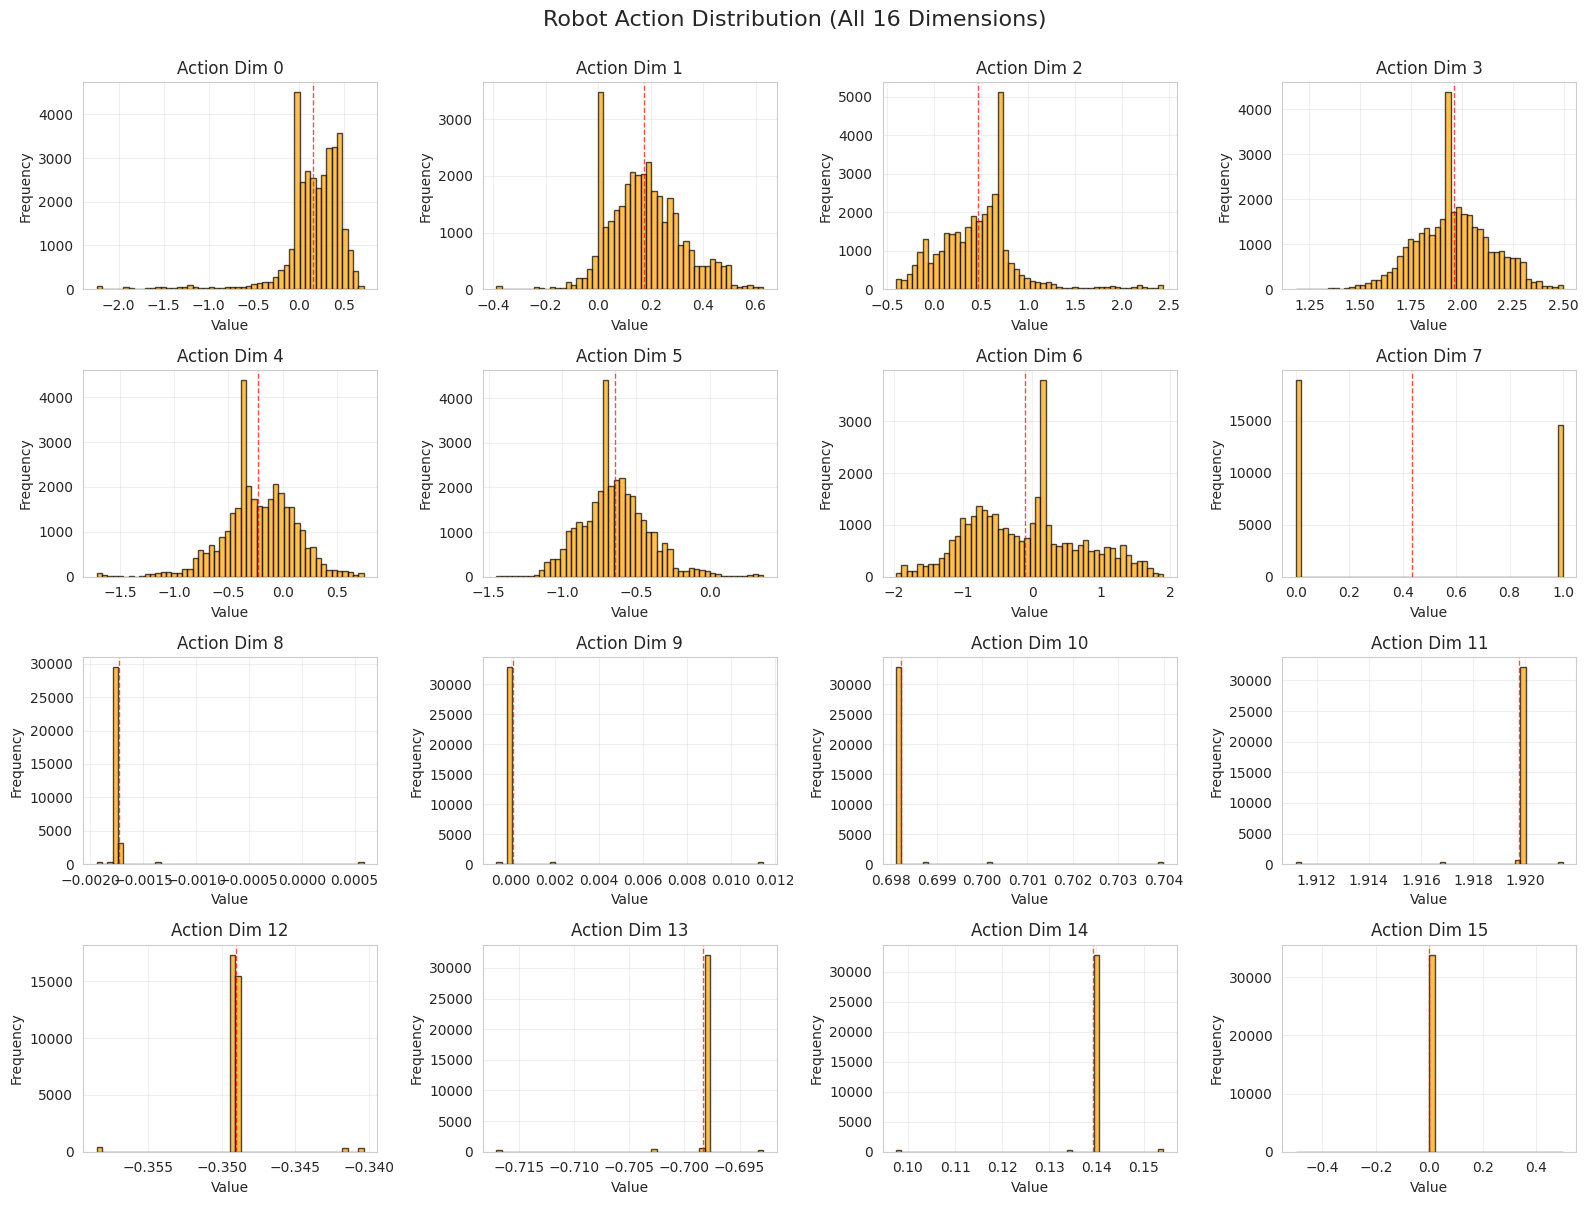

In [10]:
# Plot action distributions
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(16):
    axes[i].hist(all_actions[:, i], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[i].set_title(f'Action Dim {i}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # Add mean line
    mean_val = all_actions[:, i].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Robot Action Distribution (All 16 Dimensions)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3012/1863036169.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([all_actions[:, i] for i in range(16)],


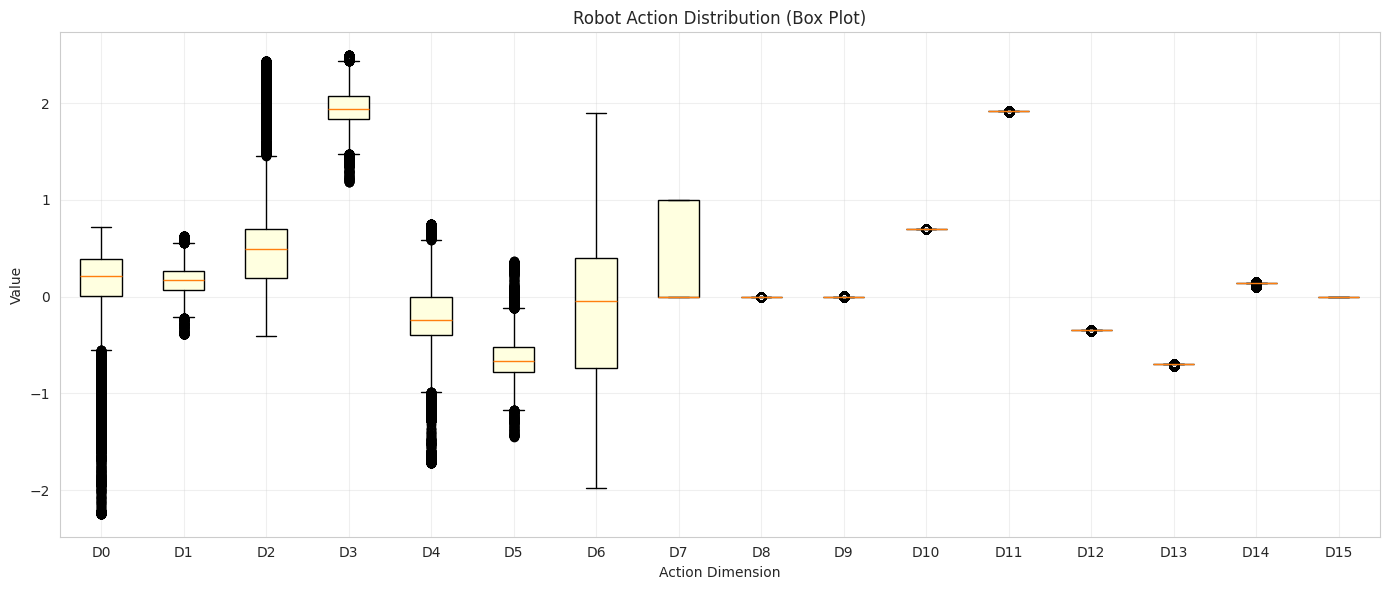

In [11]:
# Box plot for all action dimensions
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot([all_actions[:, i] for i in range(16)], 
                 labels=[f'D{i}' for i in range(16)],
                 patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightyellow')

ax.set_xlabel('Action Dimension')
ax.set_ylabel('Value')
ax.set_title('Robot Action Distribution (Box Plot)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Joint Velocity (qvel) Distribution

In [12]:
# Qvel statistics
print("Joint Velocity Statistics (14 dimensions):")
print("=" * 60)
print(f"Shape: {all_qvels.shape}")
print(f"\nPer-dimension statistics:")
print(f"{'Dim':<5} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for i in range(all_qvels.shape[1]):
    print(f"{i:<5} {all_qvels[:, i].mean():<12.6f} {all_qvels[:, i].std():<12.6f} {all_qvels[:, i].min():<12.6f} {all_qvels[:, i].max():<12.6f}")

Joint Velocity Statistics (14 dimensions):
Shape: (33865, 14)

Per-dimension statistics:
Dim   Mean         Std          Min          Max         
------------------------------------------------------------
0     0.016870     0.130893     -0.631405    0.558678    
1     0.014337     0.067014     -0.341322    0.394215    
2     -0.043077    0.145625     -0.667769    0.552066    
3     -0.001439    0.088413     -0.549587    0.400000    
4     0.021900     0.142099     -0.650495    0.603960    
5     0.008070     0.113292     -0.545545    0.587129    
6     -0.063258    0.246410     -0.769307    0.758416    
7     0.000003     0.000781     -0.004959    0.004959    
8     0.000001     0.000761     -0.004959    0.004959    
9     -0.000005    0.000567     -0.004959    0.004959    
10    0.000006     0.000675     -0.004959    0.004959    
11    0.000001     0.000185     -0.006931    0.006931    
12    -0.000000    0.000499     -0.006931    0.006931    
13    -0.000000    0.000338     -0.006

/tmp/ipykernel_3012/3966718322.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([all_qvels[:, i] for i in range(14)],


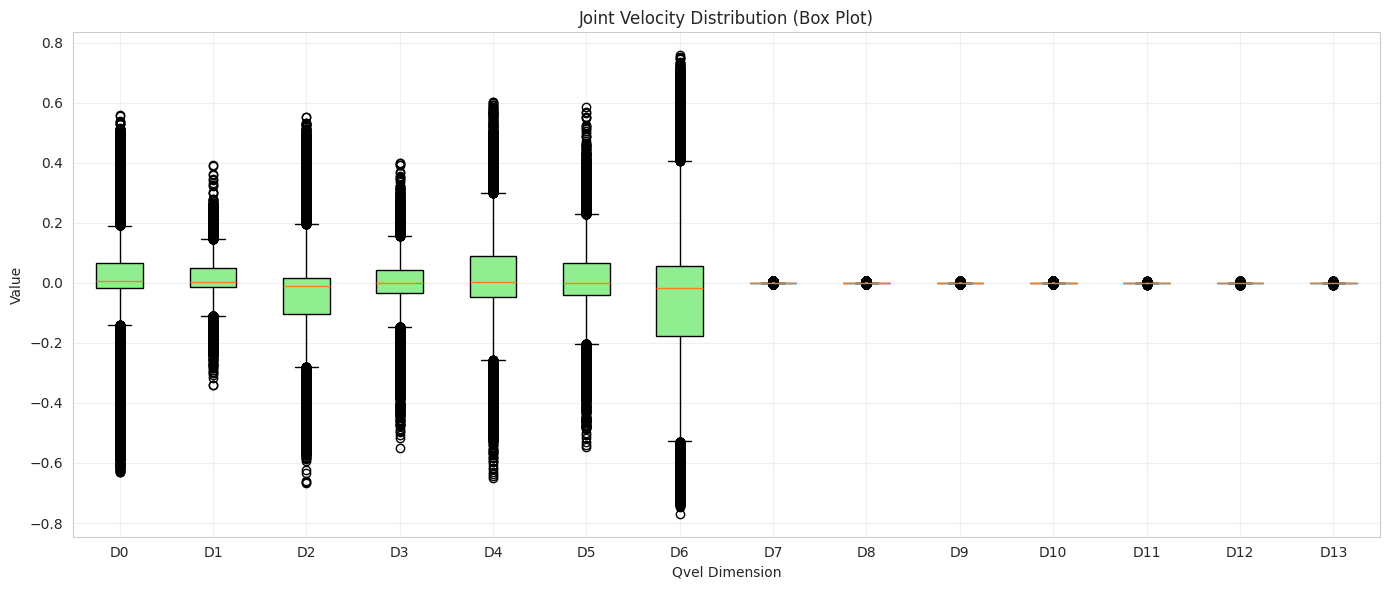

In [13]:
# Box plot for qvel
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot([all_qvels[:, i] for i in range(14)], 
                 labels=[f'D{i}' for i in range(14)],
                 patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')

ax.set_xlabel('Qvel Dimension')
ax.set_ylabel('Value')
ax.set_title('Joint Velocity Distribution (Box Plot)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## End-Effector Position Distribution

In [14]:
# EEF position statistics
print("End-Effector Position Statistics (12 dimensions):")
print("=" * 60)
print(f"Shape: {all_eef_pos.shape}")
print(f"\nPer-dimension statistics:")
print(f"{'Dim':<5} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-" * 60)
for i in range(all_eef_pos.shape[1]):
    print(f"{i:<5} {all_eef_pos[:, i].mean():<12.6f} {all_eef_pos[:, i].std():<12.6f} {all_eef_pos[:, i].min():<12.6f} {all_eef_pos[:, i].max():<12.6f}")

End-Effector Position Statistics (12 dimensions):
Shape: (33865, 12)

Per-dimension statistics:
Dim   Mean         Std          Min          Max         
------------------------------------------------------------
0     0.559417     0.106498     0.251309     0.823307    
1     -0.390423    0.123707     -0.718391    -0.075924   
2     0.400751     0.071638     0.239153     0.535369    
3     0.007821     0.125957     -0.601368    0.492708    
4     -0.431885    0.148731     -1.090716    -0.044509   
5     -0.829317    0.504579     -2.779581    0.873726    
6     0.590044     0.000005     0.590022     0.590069    
7     -0.445133    0.000006     -0.445165    -0.445103   
8     0.447226     0.000007     0.447202     0.447258    
9     0.055155     0.000013     0.055119     0.055274    
10    -0.604251    0.000012     -0.604304    -0.604206   
11    -0.742450    0.000029     -0.742507    -0.742172   


/tmp/ipykernel_3012/3144539381.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([all_eef_pos[:, i] for i in range(12)],


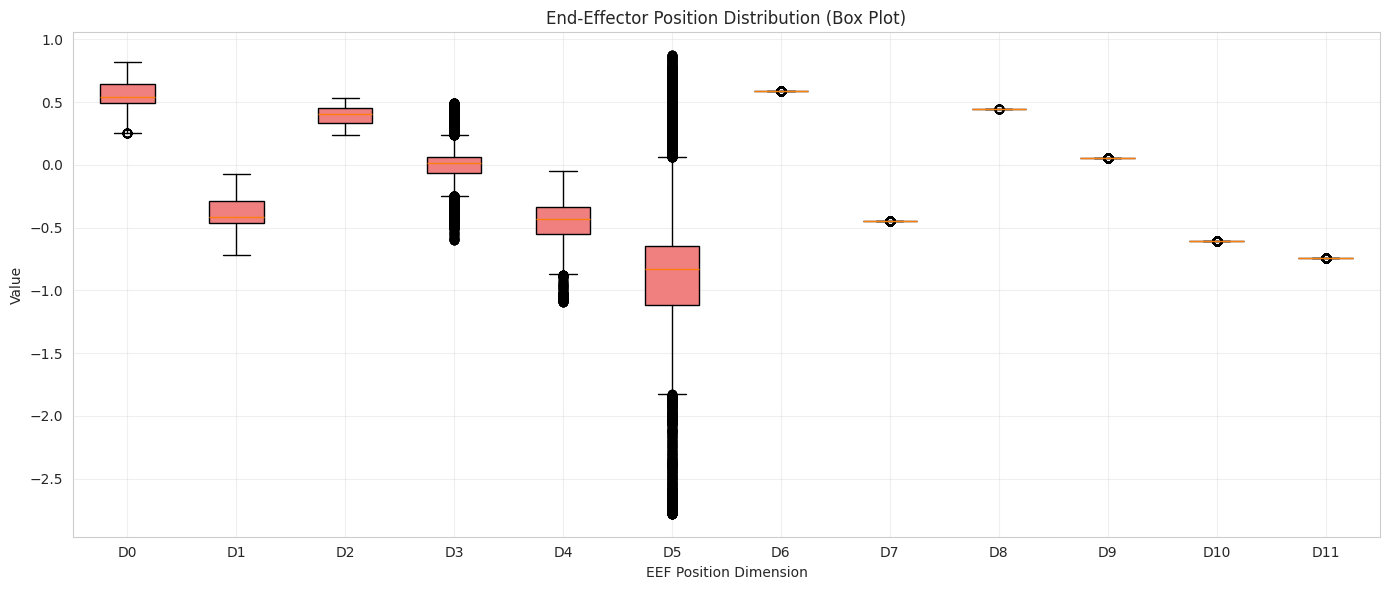

In [15]:
# Box plot for EEF position
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot([all_eef_pos[:, i] for i in range(12)], 
                 labels=[f'D{i}' for i in range(12)],
                 patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')

ax.set_xlabel('EEF Position Dimension')
ax.set_ylabel('Value')
ax.set_title('End-Effector Position Distribution (Box Plot)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary Statistics

In [16]:
print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"\nTotal Episodes: {len(episode_lengths)}")
print(f"  Success: {episode_categories.count('success')}")
print(f"  Failure: {episode_categories.count('failure')}")
print(f"\nTotal Frames: {len(all_states):,}")
print(f"\nEpisode Length:")
print(f"  Mean: {episode_lengths.mean():.1f} frames ({episode_durations.mean():.2f}s)")
print(f"  Range: {episode_lengths.min()}-{episode_lengths.max()} frames")
print(f"\nData Dimensions:")
print(f"  State: {all_states.shape[1]} dimensions")
print(f"  Action: {all_actions.shape[1]} dimensions")
print(f"  Qvel: {all_qvels.shape[1]} dimensions")
print(f"  EEF Position: {all_eef_pos.shape[1]} dimensions")
print("=" * 60)


DATASET SUMMARY

Total Episodes: 100
  Success: 70
  Failure: 30

Total Frames: 33,865

Episode Length:
  Mean: 338.6 frames (15.93s)
  Range: 211-541 frames

Data Dimensions:
  State: 16 dimensions
  Action: 16 dimensions
  Qvel: 14 dimensions
  EEF Position: 12 dimensions


In [17]:
# Calculate action magnitudes first
action_magnitudes = np.linalg.norm(all_actions, axis=1)

# Save comprehensive statistics to JSON
stats_summary = {
    "dataset_info": {
        "total_episodes": len(episode_lengths),
        "total_frames": len(all_states),
        "success_episodes": episode_categories.count('success'),
        "failure_episodes": episode_categories.count('failure')
    },
    "episode_stats": {
        "length_mean": float(episode_lengths.mean()),
        "length_std": float(episode_lengths.std()),
        "length_min": int(episode_lengths.min()),
        "length_max": int(episode_lengths.max()),
        "duration_mean": float(episode_durations.mean()),
        "duration_std": float(episode_durations.std())
    },
    "state_stats": {
        "dimensions": int(all_states.shape[1]),
        "mean_per_dim": all_states.mean(axis=0).tolist(),
        "std_per_dim": all_states.std(axis=0).tolist(),
        "min_per_dim": all_states.min(axis=0).tolist(),
        "max_per_dim": all_states.max(axis=0).tolist()
    },
    "action_stats": {
        "dimensions": int(all_actions.shape[1]),
        "mean_per_dim": all_actions.mean(axis=0).tolist(),
        "std_per_dim": all_actions.std(axis=0).tolist(),
        "min_per_dim": all_actions.min(axis=0).tolist(),
        "max_per_dim": all_actions.max(axis=0).tolist(),
        "magnitude_mean": float(action_magnitudes.mean()),
        "magnitude_std": float(action_magnitudes.std())
    },
    "qvel_stats": {
        "dimensions": int(all_qvels.shape[1]),
        "mean_per_dim": all_qvels.mean(axis=0).tolist(),
        "std_per_dim": all_qvels.std(axis=0).tolist()
    },
    "eef_stats": {
        "dimensions": int(all_eef_pos.shape[1]),
        "mean_per_dim": all_eef_pos.mean(axis=0).tolist(),
        "std_per_dim": all_eef_pos.std(axis=0).tolist()
    }
}

# Save to JSON file
output_file = base_dir / "dataset_statistics.json"
with open(output_file, 'w') as f:
    json.dump(stats_summary, f, indent=2)

print(f"Statistics saved to: {output_file}")
print("\nDataset analysis complete!")

Statistics saved to: /root/autodl-tmp/data_lerobot/dataset_statistics.json

Dataset analysis complete!


## Save Statistics Summary

In [18]:
# Check for data quality issues
print("Data Quality Checks:")
print("=" * 60)

# Check for NaN or Inf values
nan_states = np.isnan(all_states).sum()
nan_actions = np.isnan(all_actions).sum()
inf_states = np.isinf(all_states).sum()
inf_actions = np.isinf(all_actions).sum()

print(f"\nNaN values:")
print(f"  States: {nan_states}")
print(f"  Actions: {nan_actions}")
print(f"\nInf values:")
print(f"  States: {inf_states}")
print(f"  Actions: {inf_actions}")

# Check for constant values (zero variance)
state_variances = np.var(all_states, axis=0)
action_variances = np.var(all_actions, axis=0)

zero_var_states = np.sum(state_variances < 1e-10)
zero_var_actions = np.sum(action_variances < 1e-10)

print(f"\nDimensions with near-zero variance:")
print(f"  States: {zero_var_states} out of {all_states.shape[1]}")
print(f"  Actions: {zero_var_actions} out of {all_actions.shape[1]}")

if zero_var_states > 0:
    print(f"  State dimensions with zero variance: {np.where(state_variances < 1e-10)[0]}")
if zero_var_actions > 0:
    print(f"  Action dimensions with zero variance: {np.where(action_variances < 1e-10)[0]}")

# Check for outliers (values beyond 3 standard deviations)
state_outliers = 0
action_outliers = 0

for i in range(all_states.shape[1]):
    mean, std = all_states[:, i].mean(), all_states[:, i].std()
    outliers = np.sum(np.abs(all_states[:, i] - mean) > 3 * std)
    state_outliers += outliers

for i in range(all_actions.shape[1]):
    mean, std = all_actions[:, i].mean(), all_actions[:, i].std()
    outliers = np.sum(np.abs(all_actions[:, i] - mean) > 3 * std)
    action_outliers += outliers

print(f"\nOutliers (>3σ from mean):")
print(f"  States: {state_outliers} ({100*state_outliers/all_states.size:.3f}%)")
print(f"  Actions: {action_outliers} ({100*action_outliers/all_actions.size:.3f}%)")

print("\n" + "=" * 60)
if nan_states == 0 and nan_actions == 0 and inf_states == 0 and inf_actions == 0:
    print("✓ No NaN or Inf values detected - data is clean!")
else:
    print("⚠ Warning: Data contains NaN or Inf values!")

Data Quality Checks:

NaN values:
  States: 0
  Actions: 0

Inf values:
  States: 0
  Actions: 0

Dimensions with near-zero variance:
  States: 3 out of 16
  Actions: 1 out of 16
  State dimensions with zero variance: [ 8  9 15]
  Action dimensions with zero variance: [15]

Outliers (>3σ from mean):
  States: 4443 (0.820%)
  Actions: 6496 (1.199%)

✓ No NaN or Inf values detected - data is clean!


## Data Quality Checks

Action Smoothness Statistics:
Mean action change: 0.025235
Std action change: 0.099314
Max action change: 3.239077


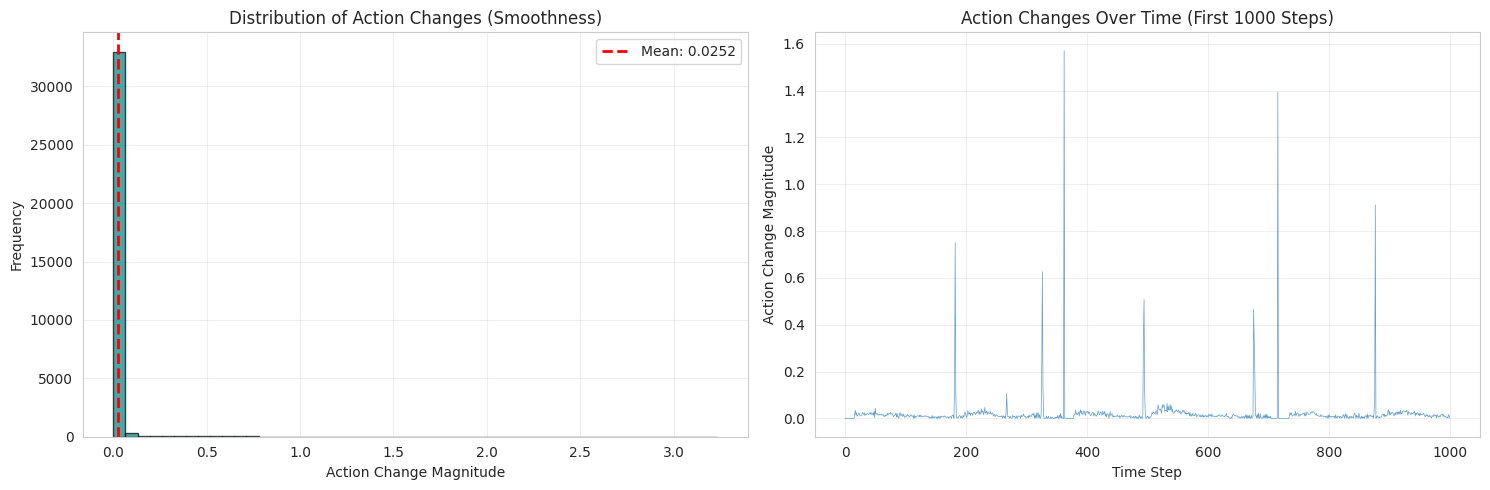

In [19]:
# Analyze action smoothness (consecutive action differences)
action_deltas = np.diff(all_actions, axis=0)
action_delta_magnitudes = np.linalg.norm(action_deltas, axis=1)

print("Action Smoothness Statistics:")
print("=" * 60)
print(f"Mean action change: {action_delta_magnitudes.mean():.6f}")
print(f"Std action change: {action_delta_magnitudes.std():.6f}")
print(f"Max action change: {action_delta_magnitudes.max():.6f}")

# Plot action smoothness
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of action changes
axes[0].hist(action_delta_magnitudes, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].axvline(action_delta_magnitudes.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {action_delta_magnitudes.mean():.4f}')
axes[0].set_xlabel('Action Change Magnitude')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Action Changes (Smoothness)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time series of action changes (first 1000 steps)
sample_len = min(1000, len(action_delta_magnitudes))
axes[1].plot(action_delta_magnitudes[:sample_len], alpha=0.7, linewidth=0.5)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Action Change Magnitude')
axes[1].set_title(f'Action Changes Over Time (First {sample_len} Steps)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Trajectory Smoothness Analysis

Action Magnitude Statistics:
Mean: 3.307234
Std: 0.235365
Min: 2.933966
Max: 4.722870
Median: 3.254744


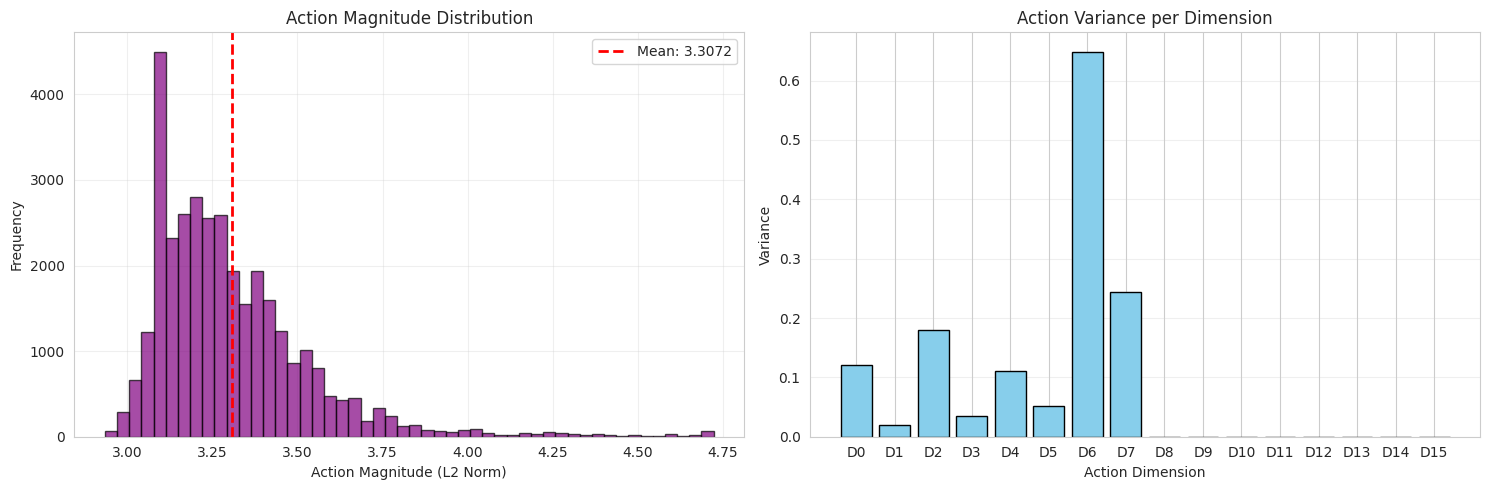


Action Variance by Dimension:
Dimension 0: 0.12096384
Dimension 1: 0.02007840
Dimension 2: 0.18041459
Dimension 3: 0.03422479
Dimension 4: 0.11126807
Dimension 5: 0.05163002
Dimension 6: 0.64885098
Dimension 7: 0.24388602
Dimension 8: 0.00000005
Dimension 9: 0.00000132
Dimension 10: 0.00000042
Dimension 11: 0.00000156
Dimension 12: 0.00000229
Dimension 13: 0.00000399
Dimension 14: 0.00001994
Dimension 15: 0.00000000


In [20]:
# Analyze action magnitudes
action_magnitudes = np.linalg.norm(all_actions, axis=1)

print("Action Magnitude Statistics:")
print("=" * 60)
print(f"Mean: {action_magnitudes.mean():.6f}")
print(f"Std: {action_magnitudes.std():.6f}")
print(f"Min: {action_magnitudes.min():.6f}")
print(f"Max: {action_magnitudes.max():.6f}")
print(f"Median: {np.median(action_magnitudes):.6f}")

# Per-dimension variance
action_variance = np.var(all_actions, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Action magnitude distribution
axes[0].hist(action_magnitudes, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(action_magnitudes.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {action_magnitudes.mean():.4f}')
axes[0].set_xlabel('Action Magnitude (L2 Norm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Action Magnitude Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-dimension variance
axes[1].bar(range(16), action_variance, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Action Dimension')
axes[1].set_ylabel('Variance')
axes[1].set_title('Action Variance per Dimension')
axes[1].set_xticks(range(16))
axes[1].set_xticklabels([f'D{i}' for i in range(16)])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nAction Variance by Dimension:")
print("=" * 60)
for i, var in enumerate(action_variance):
    print(f"Dimension {i}: {var:.8f}")

## Action Magnitude and Variance Analysis

Computing state-action correlations...


/tmp/ipykernel_3012/1410197942.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(state_sample[:, i], action_sample[:, j])


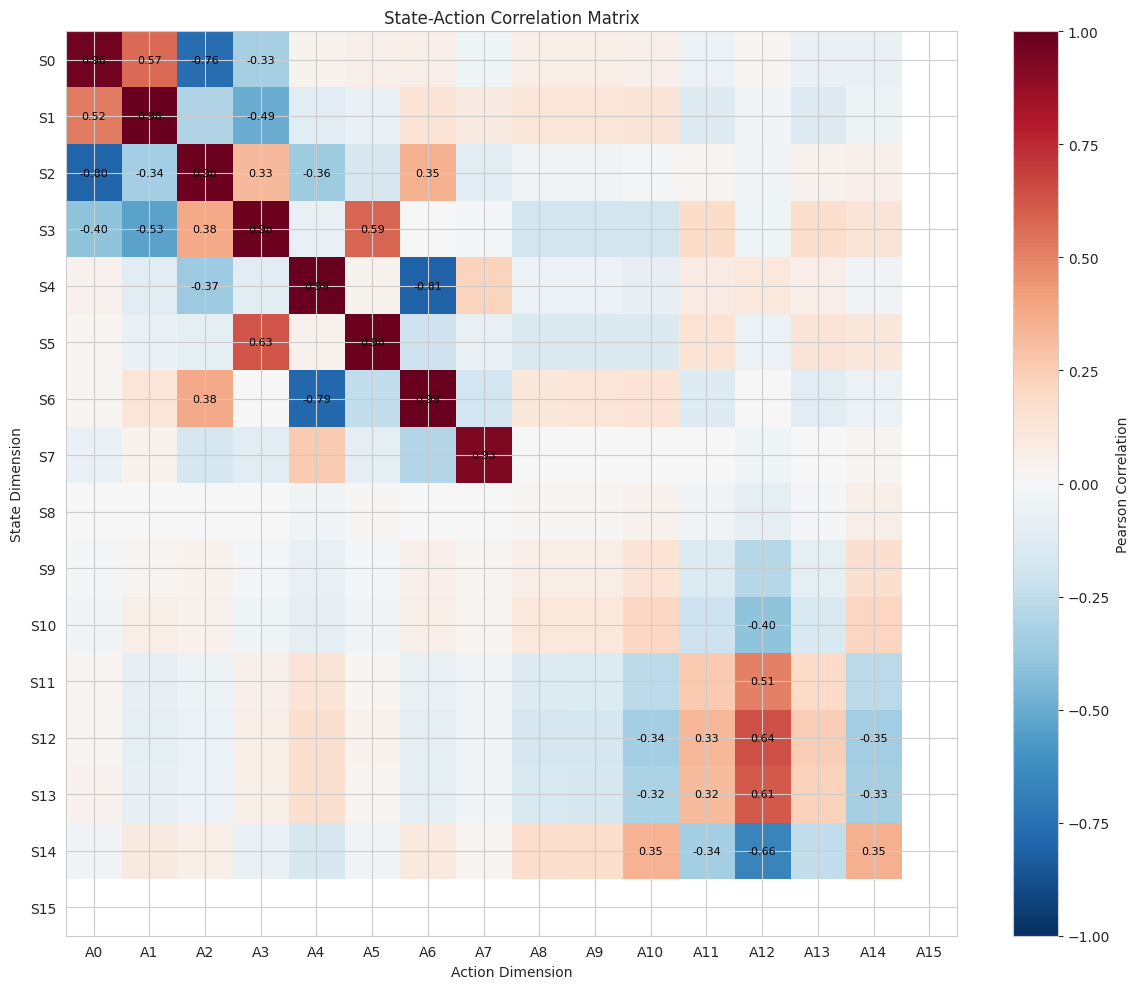


Strongest State-Action Correlations (|r| > 0.5):
State[0] <-> Action[0]: 0.965
State[0] <-> Action[1]: 0.566
State[0] <-> Action[2]: -0.759
State[1] <-> Action[0]: 0.520
State[1] <-> Action[1]: 0.985
State[2] <-> Action[0]: -0.802
State[2] <-> Action[2]: 0.977
State[3] <-> Action[1]: -0.532
State[3] <-> Action[3]: 0.980
State[3] <-> Action[5]: 0.585
State[4] <-> Action[4]: 0.987
State[4] <-> Action[6]: -0.812
State[5] <-> Action[3]: 0.626
State[5] <-> Action[5]: 0.984
State[6] <-> Action[4]: -0.785
State[6] <-> Action[6]: 0.990
State[7] <-> Action[7]: 0.934
State[11] <-> Action[12]: 0.506
State[12] <-> Action[12]: 0.645
State[13] <-> Action[12]: 0.614
State[14] <-> Action[12]: -0.658


In [21]:
# Compute correlation between states and actions
from scipy.stats import pearsonr

# Sample data for correlation (use every 10th point to speed up)
sample_size = min(10000, len(all_states))
sample_indices = np.random.choice(len(all_states), sample_size, replace=False)

state_sample = all_states[sample_indices]
action_sample = all_actions[sample_indices]

# Compute correlation matrix between state and action dimensions
print("Computing state-action correlations...")
correlations = np.zeros((16, 16))

for i in range(16):
    for j in range(16):
        corr, _ = pearsonr(state_sample[:, i], action_sample[:, j])
        correlations[i, j] = corr

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(correlations, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(16))
ax.set_yticks(range(16))
ax.set_xticklabels([f'A{i}' for i in range(16)])
ax.set_yticklabels([f'S{i}' for i in range(16)])
ax.set_xlabel('Action Dimension')
ax.set_ylabel('State Dimension')
ax.set_title('State-Action Correlation Matrix')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Pearson Correlation')

# Add correlation values
for i in range(16):
    for j in range(16):
        if abs(correlations[i, j]) > 0.3:  # Only show significant correlations
            text = ax.text(j, i, f'{correlations[i, j]:.2f}',
                         ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

# Print strongest correlations
print("\nStrongest State-Action Correlations (|r| > 0.5):")
print("=" * 60)
for i in range(16):
    for j in range(16):
        if abs(correlations[i, j]) > 0.5:
            print(f"State[{i}] <-> Action[{j}]: {correlations[i, j]:.3f}")

## State-Action Correlation Analysis